import librarires

In [ ]:
import os
import zipfile
import random

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


SETING SEED VALUE

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random Seed Set Successfully")

Random Seed Set Successfully


EXTRACTING THE DATASET

In [ ]:
zip_path = "archive (5).zip"

extract_path = "MNIST"

if not os.path.exists(extract_path):

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


LOADING THE DATASET

In [ ]:
def load_images(folder):

    images = []
    labels = []

    for digit in sorted(os.listdir(folder)):

        digit_folder = os.path.join(folder, digit)

        if not os.path.isdir(digit_folder):
            continue

        for image_name in os.listdir(digit_folder):

            image_path = os.path.join(digit_folder, image_name)

            image = Image.open(image_path).convert("L")

            image = np.array(image)

            images.append(image)

            labels.append(int(digit))

    images = np.array(images)
    labels = np.array(labels)

    return images, labels

SPLITING TRAIN AND TEST DATA

In [ ]:
train_folder = os.path.join(extract_path, "mnist_png", "training")

test_folder = os.path.join(extract_path, "mnist_png", "testing")

print("Train Folder :", train_folder)
print("Test Folder :", test_folder)

Train Folder : MNIST/mnist_png/training
Test Folder : MNIST/mnist_png/testing


In [ ]:
X_train, y_train = load_images(train_folder)

X_test, y_test = load_images(test_folder)

print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)

Training Images : (60000, 28, 28)
Testing Images : (10000, 28, 28)


VISUALIZING THE DATASSET

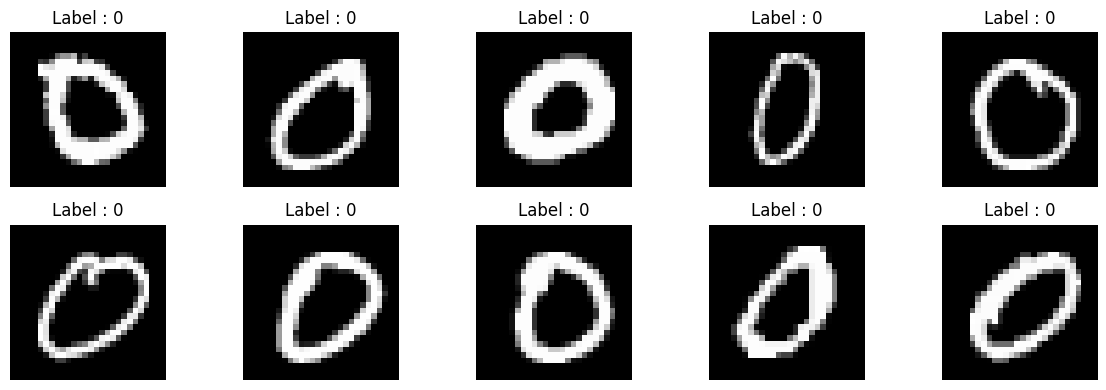

In [ ]:
plt.figure(figsize=(12,4))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i], cmap="gray")

    plt.title(f"Label : {y_train[i]}")

    plt.axis("off")

plt.tight_layout()

plt.show()

NORMALISING IMAGES

In [ ]:
X_train = X_train.astype("float32") / 255.0

X_test = X_test.astype("float32") / 255.0

# Add Channel Dimension
X_train = np.expand_dims(X_train, axis=-1)

X_test = np.expand_dims(X_test, axis=-1)

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


GENERATING GAUSSIAN NOISE

In [ ]:
noise_factor = 0.45

train_noise = np.random.normal(
    loc=0.0,
    scale=noise_factor,
    size=X_train.shape
)

test_noise = np.random.normal(
    loc=0.0,
    scale=noise_factor,
    size=X_test.shape
)

X_train_noisy = np.clip(
    X_train + train_noise,
    0.,
    1.
)

X_test_noisy = np.clip(
    X_test + test_noise,
    0.,
    1.
)

print("Noise Added Successfully")

Noise Added Successfully


VISUALISING NOISE (Original vs Noisy Images)

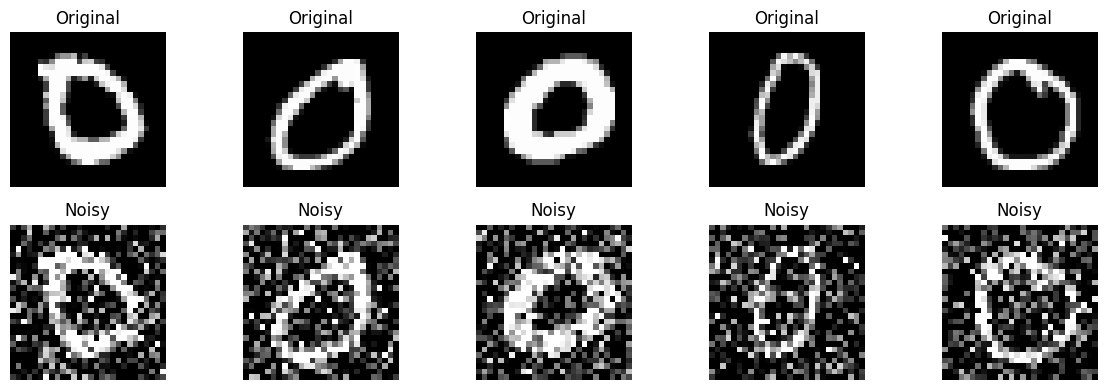

In [ ]:
plt.figure(figsize=(12,4))

for i in range(5):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i].squeeze(), cmap="gray")

    plt.title("Original")

    plt.axis("off")

    plt.subplot(2,5,i+6)

    plt.imshow(X_train_noisy[i].squeeze(), cmap="gray")

    plt.title("Noisy")

    plt.axis("off")

plt.tight_layout()

plt.show()

CONVOLUTIONAL DENOISING AUTOENCODER

In [ ]:
# Input image size
INPUT_SHAPE = (28, 28, 1)

# input layer
inputs = layers.Input(shape=INPUT_SHAPE, name="Input_Image")

# ENCODER : The encoder compresses the noisy image into latent representation while preserving important features

x = layers.Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation="relu",
    padding="same",
    name="Encoder_Conv1"
)(inputs)

x = layers.MaxPooling2D(
    pool_size=(2,2),
    padding="same",
    name="Encoder_Pool1"
)(x)

# Output Shape -> 14 x 14 x 32

x = layers.Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation="relu",
    padding="same",
    name="Encoder_Conv2"
)(x)

x = layers.MaxPooling2D(
    pool_size=(2,2),
    padding="same",
    name="Encoder_Pool2"
)(x)

# Output Shape -> 7 x 7 x 64


# ----- Latent Space -----
latent = layers.Conv2D(
    filters=128,
    kernel_size=(3,3),
    activation="relu",
    padding="same",
    name="Latent_Space"
)(x)

# Output Shape -> 7 x 7 x 128

print("Encoder Built Successfully")

Encoder Built Successfully


DECODER

In [ ]:
# DECODER : It reconstructs a clean image from the latent representation

x = layers.Conv2DTranspose(
    filters=64,
    kernel_size=(3,3),
    strides=2,
    padding="same",
    activation="relu",
    name="Decoder_Up1"
)(latent)

# Output -> 14 x 14 x 64

x = layers.Conv2DTranspose(
    filters=32,
    kernel_size=(3,3),
    strides=2,
    padding="same",
    activation="relu",
    name="Decoder_Up2"
)(x)

# Output -> 28 x 28 x 32

outputs = layers.Conv2D(
    filters=1,
    kernel_size=(3,3),
    activation="sigmoid",
    padding="same",
    name="Output_Image"
)(x)

# Create Autoencoder Model
autoencoder = Model(
    inputs=inputs,
    outputs=outputs,
    name="MNIST_Denoising_Autoencoder"
)

print("Decoder Built Successfully")

Decoder Built Successfully


MODEL SUMMARAY

In [ ]:
autoencoder.summary()

Model: "MNIST_Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Conv1 (Conv2D)          │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Pool1 (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Conv2 (Conv2D)          │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Pool2 (MaxPooling2D)    │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space (Conv2D)           │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Up1 (Conv2DTranspose)   │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Up2 (Conv2DTranspose)   │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Image (Conv2D)           │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,217 (723.50 KB)

 Trainable params: 185,217 (723.50 KB)

 Non-trainable params: 0 (0.00 B)

VISUALIZING MODEL ARCHITECTURE

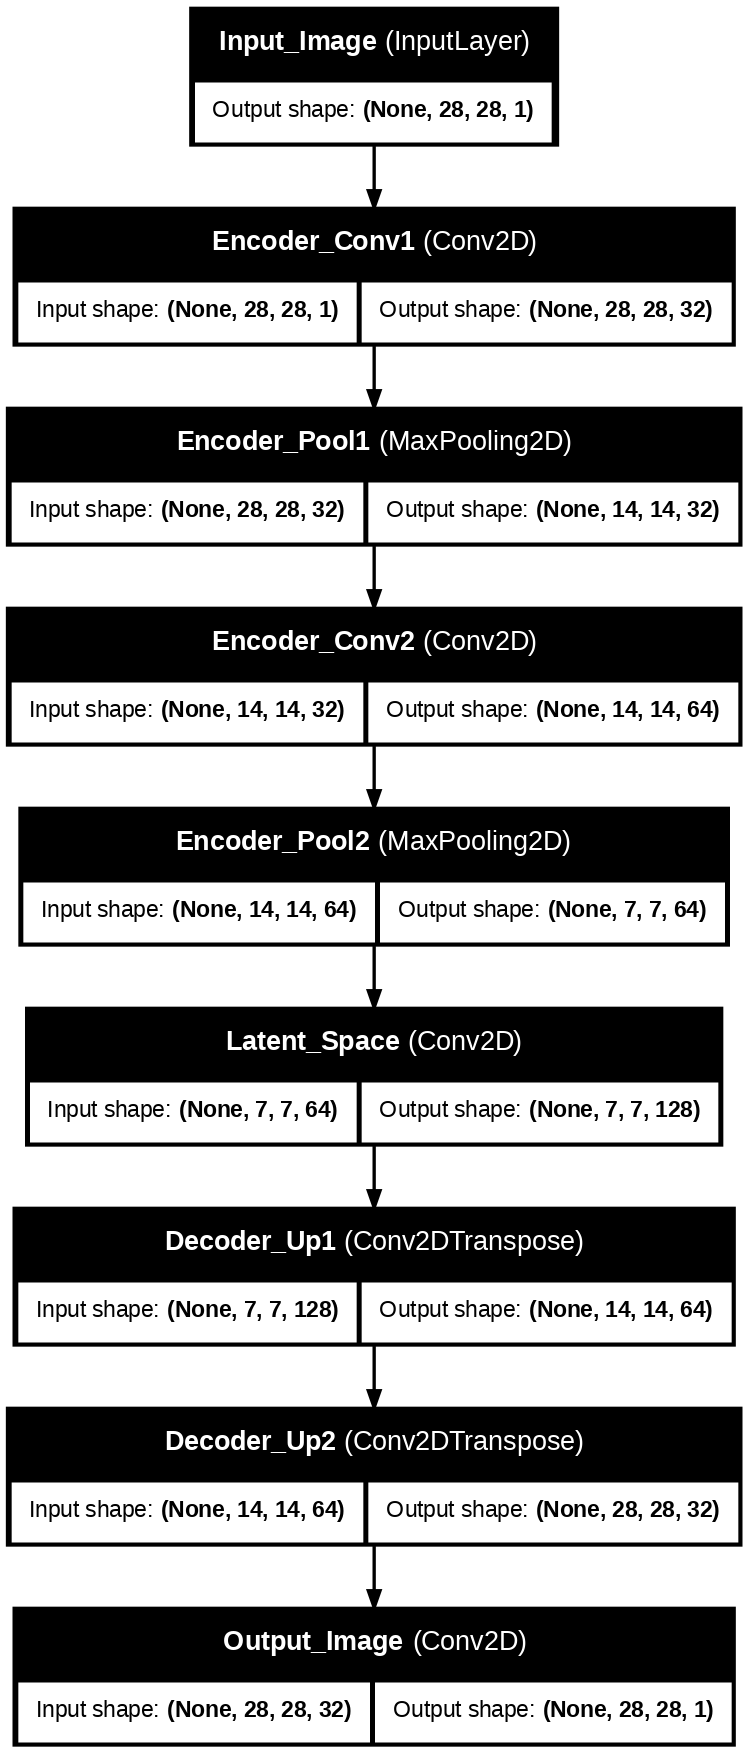

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(
    autoencoder,
    show_shapes=True,
    show_layer_names=True,
    dpi=120
)

MODEL COMPILATION

In [ ]:
optimizer = Adam(
    learning_rate=0.001
)

autoencoder.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["mae"]
)

print("Model Compiled Successfully")

Model Compiled Successfully


DEFINING CALLBACKS

In [ ]:
#  Callbacks improve training by:
#  1. Saving the best model.
#  2. Reducing learning rate if validation loss stagnates.
#  3. Stopping early to prevent overfitting.

checkpoint = ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

callbacks = [
    checkpoint,
    early_stop,
    reduce_lr
]

print("Callbacks Ready")

Callbacks Ready


MODEL TRAINING

In [ ]:
# Training Autoencoder
# Input  : Noisy Images
# Output : Clean Images
# The model learns to remove noise during training.

history = autoencoder.fit(

    X_train_noisy,
    X_train,

    validation_split=0.10,

    epochs=30,

    batch_size=128,

    shuffle=True,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2676 - mae: 0.1539
Epoch 1: val_loss improved from None to 0.10502, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - loss: 0.1622 - mae: 0.0816 - val_loss: 0.1050 - val_mae: 0.0438 - learning_rate: 0.0010
Epoch 2/30
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1020 - mae: 0.0404
Epoch 2: val_loss improved from 0.10502 to 0.09709, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1003 - mae: 0.0392 - val_loss: 0.0971 - val_mae: 0.0379 - learning_rate: 0.0010
Epoch 3/30
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0968 - mae: 0.0367
Epoch 3: val_loss improved from 0.09709 to 0.09407, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0960 - mae: 0.0362 - val_loss: 0

SAVING MODEL

In [ ]:
autoencoder.save("final_autoencoder.keras")

print("Model Saved Successfully")

Model Saved Successfully


TRAINING METRICS

In [ ]:
print("Final Training Loss :",
      history.history["loss"][-1])

print("Final Validation Loss :",
      history.history["val_loss"][-1])

print("Final Training MAE :",
      history.history["mae"][-1])

print("Final Validation MAE :",
      history.history["val_mae"][-1])

Final Training Loss : 0.08522910624742508
Final Validation Loss : 0.08729667216539383
Final Training MAE : 0.02845500409603119
Final Validation MAE : 0.030150162056088448


PLOTTING TRAINING AND VALIDATION LOSSES

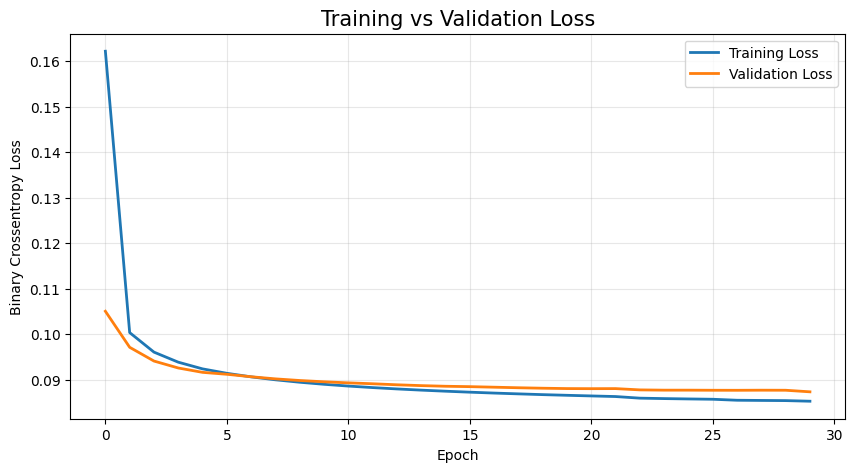

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss", linewidth=2)

plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)

plt.title("Training vs Validation Loss", fontsize=15)

plt.xlabel("Epoch")

plt.ylabel("Binary Crossentropy Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

PLOTING MAE(MEAN ABSOULTE ERROR)

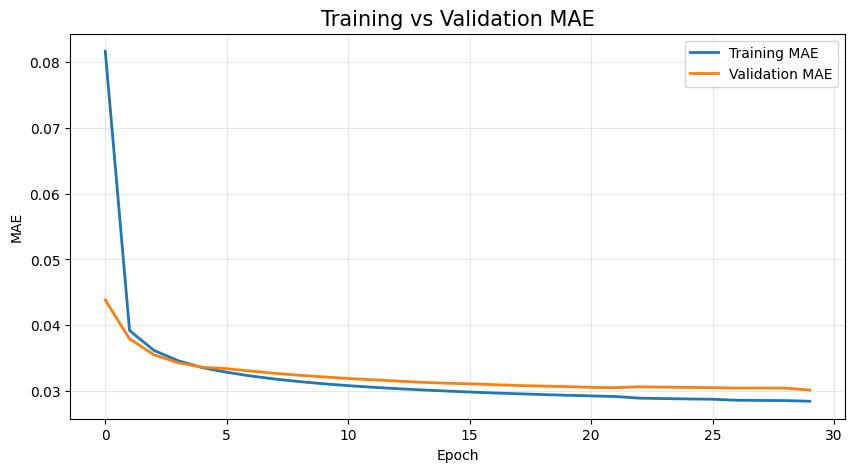

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history["mae"], label="Training MAE", linewidth=2)

plt.plot(history.history["val_mae"], label="Validation MAE", linewidth=2)

plt.title("Training vs Validation MAE", fontsize=15)

plt.xlabel("Epoch")

plt.ylabel("MAE")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

EVALUATING ON TEST DATA

In [ ]:
test_loss, test_mae = autoencoder.evaluate(
    X_test_noisy,
    X_test,
    verbose=1
)

print("="*50)
print(f"Test Loss : {test_loss:.5f}")
print(f"Test MAE  : {test_mae:.5f}")
print("="*50)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0863 - mae: 0.0292
Test Loss : 0.08625
Test MAE  : 0.02923


PREDICTING DENOISING IMAGES

In [ ]:
predicted_images = autoencoder.predict(
    X_test_noisy,
    verbose=1
)

print("Prediction Completed")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Prediction Completed


VISUALIZING IMAGES(ORIGINAL vs NOISY vs DENOISY)

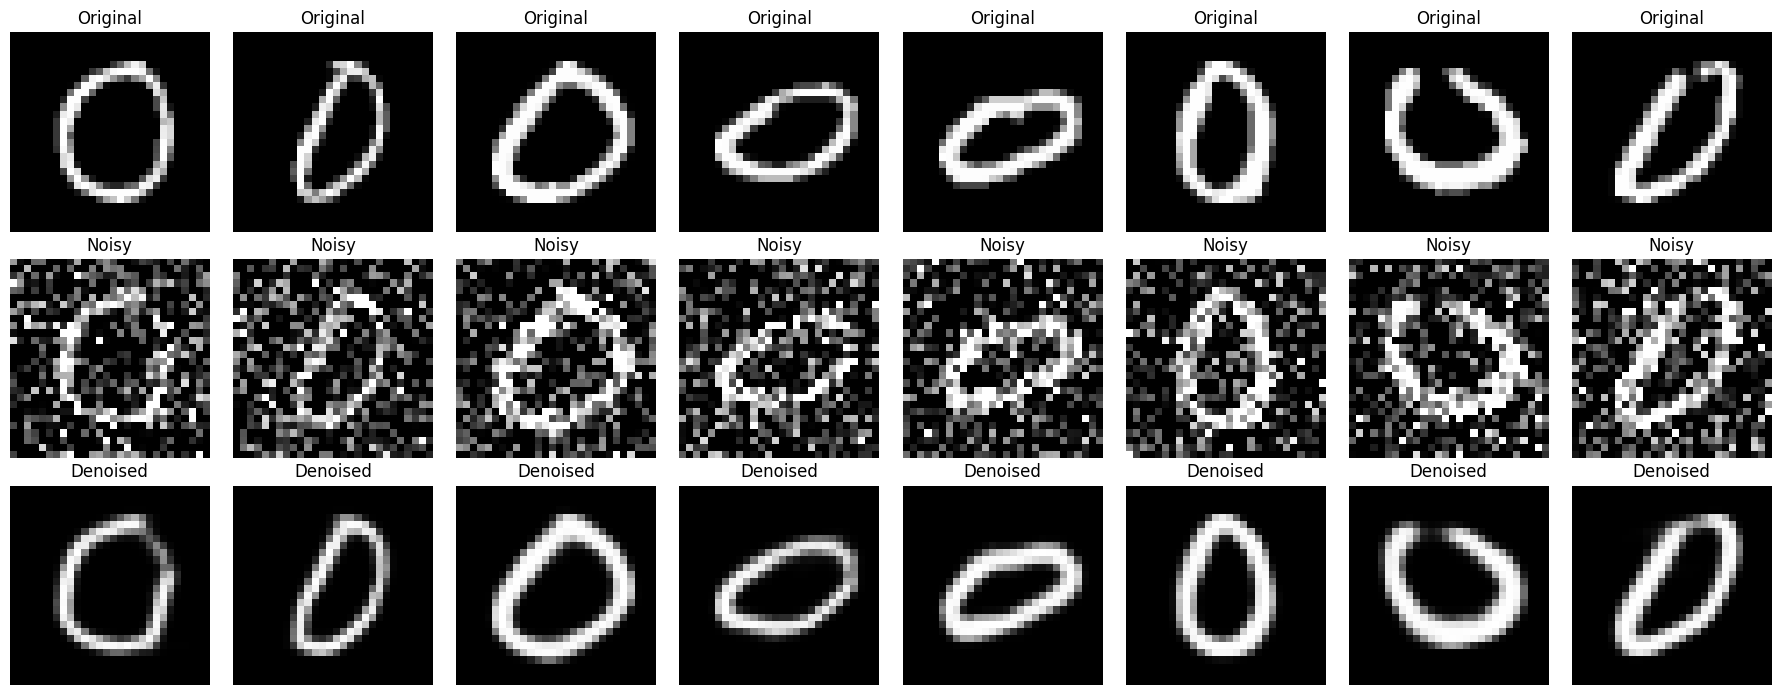

In [ ]:
num_images = 8

plt.figure(figsize=(18,7))

for i in range(num_images):

    # Original Image
    plt.subplot(3, num_images, i+1)

    plt.imshow(X_test[i].squeeze(), cmap="gray")

    plt.title("Original")

    plt.axis("off")


    # Noisy Image
    plt.subplot(3, num_images, i+1+num_images)

    plt.imshow(X_test_noisy[i].squeeze(), cmap="gray")

    plt.title("Noisy")

    plt.axis("off")


    # Reconstructed Image
    plt.subplot(3, num_images, i+1+(2*num_images))

    plt.imshow(predicted_images[i].squeeze(), cmap="gray")

    plt.title("Denoised")

    plt.axis("off")

plt.tight_layout()

plt.show()

CALCULATING PNSR(Peak Signal-to-Noise Ratio)

In [ ]:
psnr_scores = []

for i in range(len(X_test)):

    score = peak_signal_noise_ratio(
        X_test[i],
        predicted_images[i],
        data_range=1
    )

    psnr_scores.append(score)

average_psnr = np.mean(psnr_scores)

print("="*50)
print(f"Average PSNR : {average_psnr:.2f} dB")
print("="*50)

Average PSNR : 21.29 dB


CALCUTAING SSIM(Structural Similarity Index)

In [ ]:
ssim_scores = []

for i in range(len(X_test)):

    score = structural_similarity(

        X_test[i].squeeze(),

        predicted_images[i].squeeze(),

        data_range=1

    )

    ssim_scores.append(score)

average_ssim = np.mean(ssim_scores)

print("="*50)
print(f"Average SSIM : {average_ssim:.4f}")
print("="*50)

Average SSIM : 0.9003


FINAL RESULTS

In [ ]:
print("="*60)

print("Model Evaluation Summary")

print("="*60)

print(f"Training Loss        : {history.history['loss'][-1]:.5f}")

print(f"Validation Loss      : {history.history['val_loss'][-1]:.5f}")

print(f"Training MAE         : {history.history['mae'][-1]:.5f}")

print(f"Validation MAE       : {history.history['val_mae'][-1]:.5f}")

print(f"Test Loss            : {test_loss:.5f}")

print(f"Test MAE             : {test_mae:.5f}")

print(f"Average PSNR         : {average_psnr:.2f} dB")

print(f"Average SSIM         : {average_ssim:.4f}")

print("="*60)

Model Evaluation Summary
Training Loss        : 0.08523
Validation Loss      : 0.08730
Training MAE         : 0.02846
Validation MAE       : 0.03015
Test Loss            : 0.08625
Test MAE             : 0.02923
Average PSNR         : 21.29 dB
Average SSIM         : 0.9003


SAVING SAMPLE PREDICITON

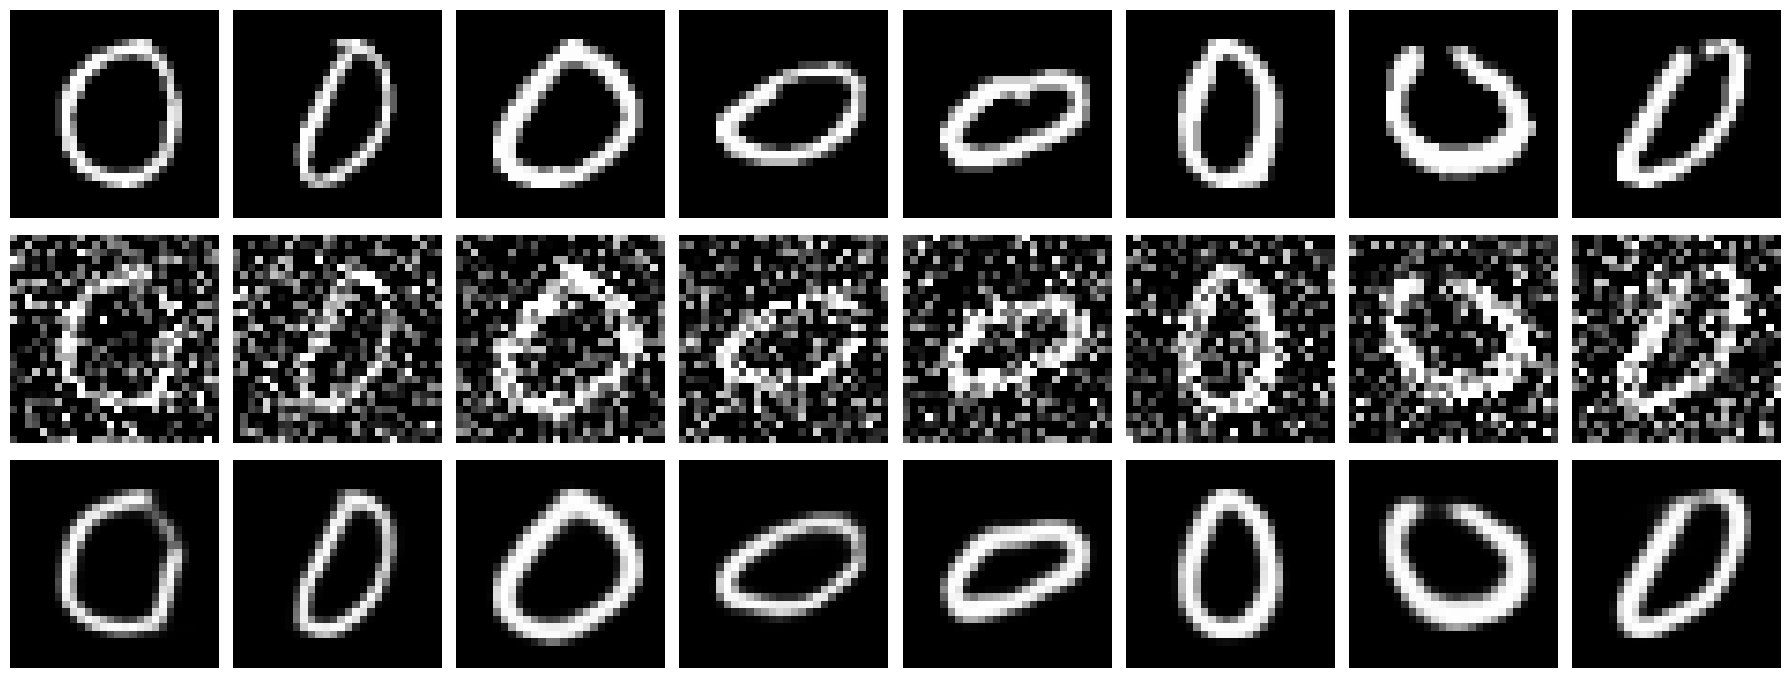

Image Saved Successfully


In [ ]:
plt.figure(figsize=(18,7))

for i in range(8):

    plt.subplot(3,8,i+1)

    plt.imshow(X_test[i].squeeze(), cmap="gray")

    plt.axis("off")


    plt.subplot(3,8,i+9)

    plt.imshow(X_test_noisy[i].squeeze(), cmap="gray")

    plt.axis("off")


    plt.subplot(3,8,i+17)

    plt.imshow(predicted_images[i].squeeze(), cmap="gray")

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "Denoised_Result.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Image Saved Successfully")

SAVING TRAINING GRAPH

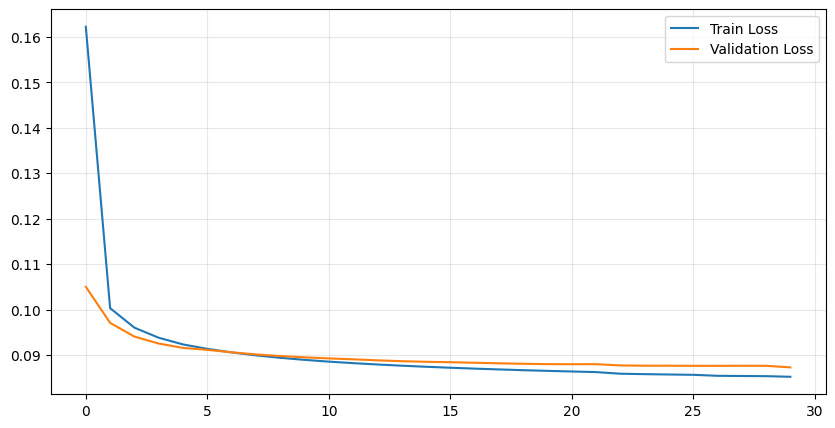

Training Graph Saved


In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Train Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    "Training_Curve.png",
    dpi=300
)

plt.show()

print("Training Graph Saved")

OBSERVATIONS :
1. The Convolutional Denoising Autoencoder successfully    reconstructs clean handwritten digits from noisy inputs.
2. Training and validation loss decreased steadily, indicating that the model learned meaningful image representations without significant overfitting.
3. The average PSNR value indicates good reconstruction quality.
4. The reconstructed images retained most of the important structural features while removing Gaussian noise.
5. Using convolutional layers instead of dense layers helped preserve spatial information, resulting in better image quality.